# FloodScan flood events + GloFAS threshold validation : Somali region, Ethiopia

Ethiopia has no SWALIM-style gauge feed on the Shabelle / Genale, so FloodScan
flooded extent per admin2 zone is the benchmark: flood events are defined from
FloodScan itself, and GloFAS reanalysis RP-threshold crossings (from
`01_glofas_return_periods.ipynb`) are scored against them.

Method:
1. Smooth each zone's daily flooded extent with a 7-day rolling mean.
2. Fit RP levels to the smoothed series' annual maxima (1998-2025) and define
   events at the FloodScan RP2 and RP3 levels: contiguous exceedances, gaps under
   14 days merged, at least 2 days long. Each event is assigned a season by its
   peak date (Gu = Mar-Jun | Kiremt = Jul-Sep | Deyr = Oct-Dec).
3. Scoring is SEASONAL: GloFAS discharge in a season's months is compared to that
   season's own RP threshold (Kiremt highland flows dominate the annual maxima,
   so an annual threshold is blind to Gu and Deyr floods by construction), and the
   resulting episodes are scored against that season's events only, with +/-7 day
   overlap tolerance (Somalia convention).
4. POD | FAR per version x station x GloFAS RP x season, plus all-season combined.

Frequency-matching note: scoring frequency-fitted GloFAS thresholds against
frequency-fitted FloodScan events is an implicit bias correction on both sides:
what is tested is timing agreement, not magnitudes. The Somalia comparison found
v4 poorly timed on the Shabelle (and blind to Deyr 2023 at Gode) while v5 fixed
both magnitude and timing: expect the version comparison here to matter.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from scipy import stats

STAGE = "dev"
PROJECT_PREFIX = "ds-aa-eth-flooding"

RP_GRID = [2, 3, 4, 5, 7, 10]
FS_BENCHMARKS = [2, 3]        # FloodScan event rarity (years)
SCORE_START, SCORE_END = "2003-01-01", "2025-12-31"
MATCH_TOLERANCE_DAYS = 7
FS_MERGE_GAP_DAYS = 14
FS_MIN_DURATION_DAYS = 2
GLOFAS_MERGE_GAP_DAYS = 7
SEASON_MONTHS = {"gu": [3, 4, 5, 6], "kiremt": [7, 8, 9], "deyr": [10, 11, 12]}


def month_season(m: int) -> str:
    for season, months in SEASON_MONTHS.items():
        if m in months:
            return season
    return "jilaal"  # Jan-Feb dry season

## Load inputs

In [2]:
mapping = stratus.load_csv_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/station_zone_mapping_all.csv", stage=STAGE
)
thresholds = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_return_periods.parquet", stage=STAGE
)
fs = stratus.load_csv_from_blob(
    f"{PROJECT_PREFIX}/processed/floodscan/floodscan_somali_eth.csv", stage=STAGE
)
fs["valid_date"] = pd.to_datetime(fs["valid_date"])

grid = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge.parquet", stage=STAGE
)
rp_pts = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_reporting_points.parquet", stage=STAGE
)
raw = pd.concat([grid, rp_pts], ignore_index=True)
rean = raw[raw["dataset"] == "reanalysis"].copy()
rean["valid_time"] = pd.to_datetime(rean["valid_time"]).dt.normalize()
rean["date"] = rean["valid_time"] - pd.Timedelta(days=1)
rean = (
    rean.sort_values(["valid_time", "product_type"])
    .drop_duplicates(["station_id", "date"], keep="last")
    .loc[:, ["station_id", "date", "discharge"]]
)
rean["version"] = "v4_0"
try:
    v5 = stratus.load_parquet_from_blob(
        f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_v5.parquet", stage=STAGE
    )
    v5["valid_time"] = pd.to_datetime(v5["valid_time"]).dt.normalize()
    v5["date"] = v5["valid_time"] - pd.Timedelta(days=1)
    v5 = (
        v5.sort_values("valid_time")
        .drop_duplicates(["station_id", "date"], keep="last")
        .loc[:, ["station_id", "date", "discharge"]]
    )
    v5["version"] = "v5_0"
    rean = pd.concat([rean, v5], ignore_index=True)
    print("v5 loaded")
except Exception as e:
    print(f"v5 not available yet ({type(e).__name__}): scoring v4 only")

VERSIONS = sorted(rean["version"].unique())
STATION_ORDER = mapping["station_id"].tolist()
ZONES = mapping[["pcode", "zone"]].drop_duplicates().set_index("pcode")["zone"].to_dict()
print(ZONES, VERSIONS)

v5 not available yet (ResourceNotFoundError): scoring v4 only
{'ET0506': 'Shabelle', 'ET0509': 'Liban', 'ET0508': 'Afder'} ['v4_0']


## FloodScan per zone : smoothed series and RP levels

In [3]:
fs_zones = {}
for pcode in ZONES:
    z = (
        fs[fs["pcode"] == pcode]
        .set_index("valid_date")["sum"]
        .asfreq("D")
        .interpolate(limit=5)
    )
    fs_zones[pcode] = z.rolling(7, center=True, min_periods=4).mean()


def gumbel_level(maxima: np.ndarray, rp: float) -> float:
    loc, scale = stats.gumbel_r.fit(maxima)
    return float(stats.gumbel_r.ppf(1 - 1 / rp, loc=loc, scale=scale))


fs_levels = {}
for pcode, s in fs_zones.items():
    am = s.groupby(s.index.year).max().dropna()
    am = am[am.index <= 2025]
    fs_levels[pcode] = {rp: gumbel_level(am.values, rp) for rp in FS_BENCHMARKS}
pd.DataFrame(fs_levels).T.rename(index=ZONES).round(0)

,2,3
Shabelle,27095.0,33907.0
Liban,2182.0,2964.0
Afder,8464.0,11002.0


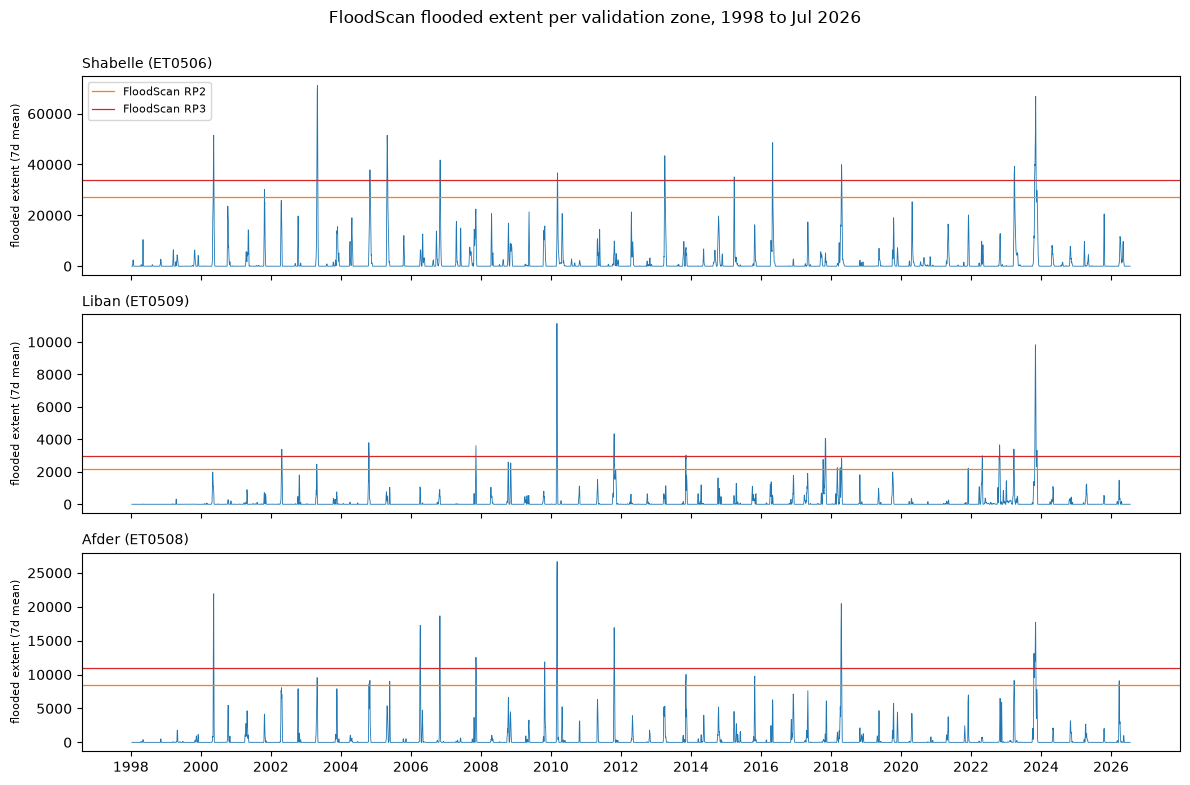

In [4]:
fig, axes = plt.subplots(len(ZONES), 1, figsize=(12, 2.6 * len(ZONES)), sharex=True)
for ax, (pcode, s) in zip(np.atleast_1d(axes), fs_zones.items()):
    ax.plot(s.index, s.values, linewidth=0.6, color="tab:blue")
    for rp, c in zip(FS_BENCHMARKS, ["tab:orange", "tab:red"]):
        ax.axhline(fs_levels[pcode][rp], color=c, linewidth=0.9, label=f"FloodScan RP{rp}")
    ax.set_title(f"{ZONES[pcode]} ({pcode})", fontsize=10, loc="left")
    ax.set_ylabel("flooded extent (7d mean)", fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle("FloodScan flooded extent per validation zone, 1998 to Jul 2026", y=1.0)
plt.tight_layout()
plt.show()

## Event extraction

In [5]:
def extract_episodes(s: pd.Series, threshold: float, merge_gap_days: int, min_duration_days: int = 1) -> pd.DataFrame:
    above = (s >= threshold).fillna(False)
    if not above.any():
        return pd.DataFrame(columns=["start", "end", "peak", "peak_date"])
    grp = (above != above.shift()).cumsum()
    runs = []
    for _, chunk in s[above].groupby(grp[above]):
        runs.append([chunk.index.min(), chunk.index.max()])
    merged = [runs[0]]
    for start, end in runs[1:]:
        if (start - merged[-1][1]).days <= merge_gap_days:
            merged[-1][1] = end
        else:
            merged.append([start, end])
    rows = []
    for start, end in merged:
        if (end - start).days + 1 < min_duration_days:
            continue
        win = s.loc[start:end]
        rows.append({"start": start, "end": end, "peak": win.max(), "peak_date": win.idxmax()})
    return pd.DataFrame(rows)


fs_events = []
for pcode, s in fs_zones.items():
    s_score = s.loc[SCORE_START:SCORE_END]
    for rp in FS_BENCHMARKS:
        ev = extract_episodes(s_score, fs_levels[pcode][rp], FS_MERGE_GAP_DAYS, FS_MIN_DURATION_DAYS)
        ev["pcode"] = pcode
        ev["zone"] = ZONES[pcode]
        ev["fs_rp"] = rp
        fs_events.append(ev)
fs_events = pd.concat(fs_events, ignore_index=True)
fs_events["season"] = fs_events["peak_date"].dt.month.map(month_season)
fs_events.groupby(["zone", "fs_rp", "season"]).agg(n_events=("start", "size"))

n_events
zone     fs_rp season          
Afder    2     deyr           8
               gu             6
         3     deyr           5
               gu             3
Liban    2     deyr          11
               gu             5
         3     deyr           6
               gu             2
Shabelle 2     deyr           3
               gu             8
         3     deyr           3
               gu             7

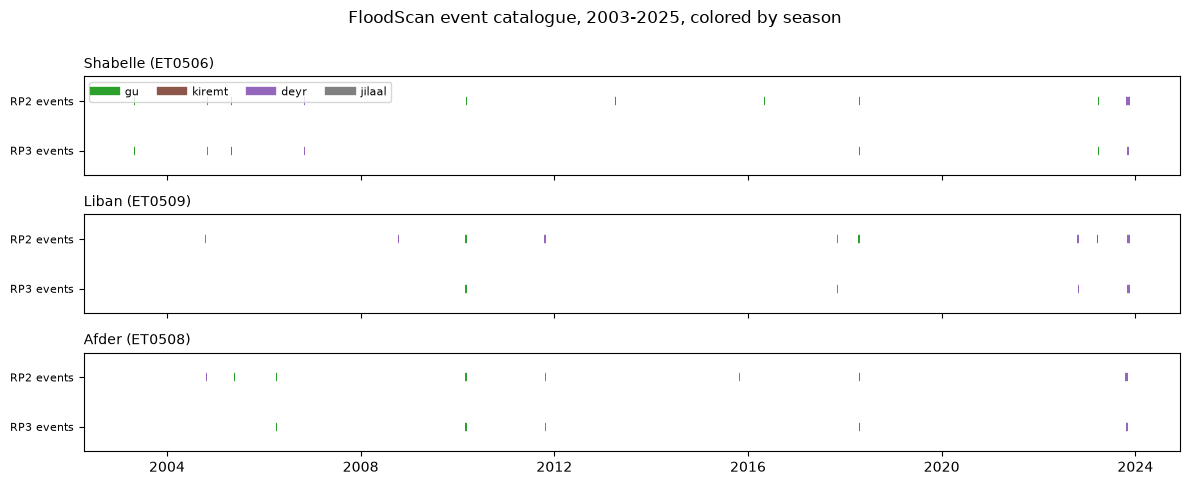

In [6]:
fig, axes = plt.subplots(len(ZONES), 1, figsize=(12, 1.6 * len(ZONES)), sharex=True)
season_colors = {"gu": "tab:green", "kiremt": "tab:brown", "deyr": "tab:purple", "jilaal": "grey"}
for ax, pcode in zip(np.atleast_1d(axes), ZONES):
    for rp, y in [(2, 1), (3, 0)]:
        ev = fs_events[(fs_events["pcode"] == pcode) & (fs_events["fs_rp"] == rp)]
        for _, e in ev.iterrows():
            ax.plot([e["start"], e["end"]], [y, y], linewidth=6,
                    color=season_colors[e["season"]], solid_capstyle="butt")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["RP3 events", "RP2 events"], fontsize=8)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{ZONES[pcode]} ({pcode})", fontsize=10, loc="left")
handles = [plt.Line2D([], [], color=c, linewidth=6, label=s) for s, c in season_colors.items()]
axes[0].legend(handles=handles, fontsize=8, ncol=4, loc="upper left")
plt.suptitle("FloodScan event catalogue, 2003-2025, colored by season", y=1.0)
plt.tight_layout()
plt.show()

## Seasonal scoring

For each version | station | season | GloFAS RP: episodes of that season's discharge
over that season's threshold, scored against that season's FloodScan events.
The `all` row pools the three seasons' episodes and events.

In [7]:
thr = thresholds.set_index(["version", "station_id", "season", "rp"])["threshold_gumbel"]


def match_counts(episodes: pd.DataFrame, events: pd.DataFrame) -> tuple:
    tol = pd.Timedelta(days=MATCH_TOLERANCE_DAYS)
    hits_ev = sum(
        ((episodes["start"] - tol <= e["end"]) & (episodes["end"] + tol >= e["start"])).any()
        for _, e in events.iterrows()
    ) if len(episodes) else 0
    hits_ep = sum(
        ((events["start"] - tol <= e["end"]) & (events["end"] + tol >= e["start"])).any()
        for _, e in episodes.iterrows()
    ) if len(events) else 0
    return hits_ev, hits_ep


scores = []
for version in VERSIONS:
    for sid in STATION_ORDER:
        pcode = mapping.set_index("station_id").loc[sid, "pcode"]
        s_full = (
            rean[(rean["station_id"] == sid) & (rean["version"] == version)]
            .set_index("date")["discharge"].asfreq("D").loc[SCORE_START:SCORE_END]
        )
        for rp in RP_GRID:
            season_parts = {}
            for season, months in SEASON_MONTHS.items():
                key = (version, sid, season, rp)
                if key not in thr.index:
                    continue
                s_season = s_full[s_full.index.month.isin(months)].asfreq("D")
                episodes = extract_episodes(s_season, thr.loc[key], GLOFAS_MERGE_GAP_DAYS)
                season_parts[season] = episodes
            for fs_rp in FS_BENCHMARKS:
                ev_all = fs_events[(fs_events["pcode"] == pcode) & (fs_events["fs_rp"] == fs_rp)]
                pooled_ep, pooled = [], {"hits_ev": 0, "n_ev": 0, "hits_ep": 0, "n_ep": 0}
                for season, episodes in season_parts.items():
                    ev = ev_all[ev_all["season"] == season]
                    hits_ev, hits_ep = match_counts(episodes, ev)
                    scores.append({
                        "version": version, "station_id": sid, "season": season,
                        "glofas_rp": rp, "fs_rp": fs_rp,
                        "n_events": len(ev), "n_episodes": len(episodes),
                        "pod": hits_ev / len(ev) if len(ev) else np.nan,
                        "far": 1 - hits_ep / len(episodes) if len(episodes) else np.nan,
                    })
                    pooled["hits_ev"] += hits_ev
                    pooled["n_ev"] += len(ev)
                    pooled["hits_ep"] += hits_ep
                    pooled["n_ep"] += len(episodes)
                scores.append({
                    "version": version, "station_id": sid, "season": "all",
                    "glofas_rp": rp, "fs_rp": fs_rp,
                    "n_events": pooled["n_ev"], "n_episodes": pooled["n_ep"],
                    "pod": pooled["hits_ev"] / pooled["n_ev"] if pooled["n_ev"] else np.nan,
                    "far": 1 - pooled["hits_ep"] / pooled["n_ep"] if pooled["n_ep"] else np.nan,
                })
scores = pd.DataFrame(scores)
scores[scores["season"] == "all"].head()

,version,station_id,season,glofas_rp,fs_rp,n_events,n_episodes,pod,far
3,v4_0,G1904,all,2,2,11,39,0.272727,0.923077
7,v4_0,G1904,all,2,3,10,39,0.300000,0.923077
11,v4_0,G1904,all,3,2,11,29,0.181818,0.931034
15,v4_0,G1904,all,3,3,10,29,0.200000,0.931034
19,v4_0,G1904,all,4,2,11,21,0.090909,0.952381


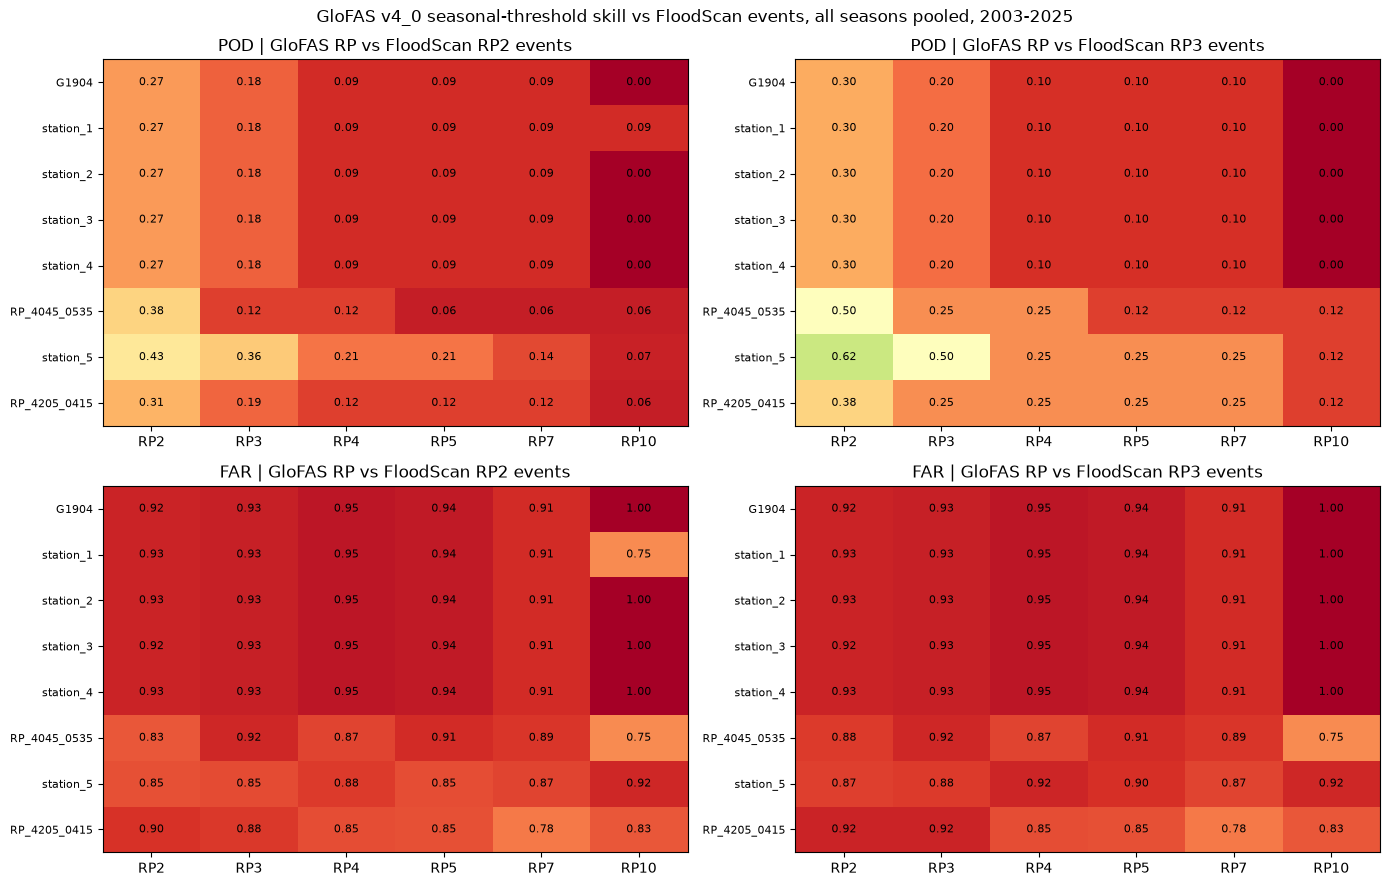

In [8]:
for version in VERSIONS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for j, fs_rp in enumerate(FS_BENCHMARKS):
        sub = scores[(scores["fs_rp"] == fs_rp) & (scores["season"] == "all") & (scores["version"] == version)]
        for i, metric in enumerate(["pod", "far"]):
            piv = sub.pivot(index="station_id", columns="glofas_rp", values=metric).reindex(STATION_ORDER)
            ax = axes[i, j]
            ax.imshow(piv.values, cmap="RdYlGn" if metric == "pod" else "RdYlGn_r", vmin=0, vmax=1, aspect="auto")
            ax.set_xticks(range(len(RP_GRID)))
            ax.set_xticklabels([f"RP{r}" for r in RP_GRID])
            ax.set_yticks(range(len(piv.index)))
            ax.set_yticklabels(piv.index, fontsize=8)
            for y in range(piv.shape[0]):
                for x in range(piv.shape[1]):
                    v = piv.values[y, x]
                    if not np.isnan(v):
                        ax.text(x, y, f"{v:.2f}", ha="center", va="center", fontsize=8)
            ax.set_title(f"{metric.upper()} | GloFAS RP vs FloodScan RP{fs_rp} events")
    plt.suptitle(f"GloFAS {version} seasonal-threshold skill vs FloodScan events, all seasons pooled, 2003-2025")
    plt.tight_layout()
    plt.show()

In [9]:
piv = (
    scores[(scores["fs_rp"] == 3) & (scores["season"] != "all")]
    .pivot_table(index=["version", "station_id", "glofas_rp"], columns="season", values=["pod", "far"])
    .round(2)
)
piv.head(36)

far                pod      
season                          deyr    gu kiremt  deyr    gu
version station_id   glofas_rp                               
v4_0    G1904        2          1.00  0.73    1.0  0.00  0.43
                     3          1.00  0.80    1.0  0.00  0.29
                     4          1.00  0.86    1.0  0.00  0.14
                     5          1.00  0.88    1.0  0.00  0.14
                     7          1.00  0.86    1.0  0.00  0.14
                     10          NaN  1.00    1.0  0.00  0.00
        RP_4045_0535 2          0.62  1.00    1.0  0.67  0.00
                     3          0.60  1.00    1.0  0.33  0.00
                     4          0.50  1.00    1.0  0.33  0.00
                     5          0.67  1.00    1.0  0.17  0.00
                     7          0.50  1.00    1.0  0.17  0.00
                     10         0.50  1.00    NaN  0.17  0.00
        RP_4205_0415 2          0.62  1.00    1.0  0.50  0.00
                     3          0.67  1.00    1.0  0.33  0.00
                     4          0.40  1.00    1.0  0.33  0.00
                     5          0.33  1.00    1.0  0.33  0.00
                     7          0.33  1.00    1.0  0.33  0.00
                     10         0.50  1.00    1.0  0.17  0.00
        station_1    2          1.00  0.73    1.0  0.00  0.43
                     3          1.00  0.80    1.0  0.00  0.29
                     4          1.00  0.86    1.0  0.00  0.14
                     5          1.00  0.88    1.0  0.00  0.14
                     7          1.00  0.86    1.0  0.00  0.14
                     10          NaN  1.00    1.0  0.00  0.00
        station_2    2          1.00  0.73    1.0  0.00  0.43
                     3          1.00  0.80    1.0  0.00  0.29
                     4          1.00  0.86    1.0  0.00  0.14
                     5          1.00  0.88    1.0  0.00  0.14
                     7          1.00  0.86    1.0  0.00  0.14
                     10          NaN  1.00    1.0  0.00  0.00
        station_3    2          1.00  0.73    1.0  0.00  0.43
                     3          1.00  0.80    1.0  0.00  0.29
                     4          1.00  0.86    1.0  0.00  0.14
                     5          1.00  0.88    1.0  0.00  0.14
                     7          1.00  0.86    1.0  0.00  0.14
                     10          NaN  1.00    1.0  0.00  0.00

## Discharge vs flooded extent correlation

Context check: rank correlation between each station's daily discharge and its
zone's smoothed flooded extent (positive-extent days only).

In [10]:
rows = []
for version in VERSIONS:
    for sid in STATION_ORDER:
        pcode = mapping.set_index("station_id").loc[sid, "pcode"]
        s = (
            rean[(rean["station_id"] == sid) & (rean["version"] == version)]
            .set_index("date")["discharge"].loc[SCORE_START:SCORE_END]
        )
        z = fs_zones[pcode].reindex(s.index)
        mask = z > 0
        rows.append({
            "version": version, "station_id": sid, "zone": ZONES[pcode],
            "spearman_all": s.corr(z, method="spearman"),
            "spearman_wet": s[mask].corr(z[mask], method="spearman"),
        })
corr = pd.DataFrame(rows)
corr.pivot_table(index="station_id", columns="version", values=["spearman_all", "spearman_wet"]).round(2)

,spearman_all,spearman_wet
version,v4_0,v4_0
station_id,,
G1904,0.20,-0.04
RP_4045_0535,0.08,0.21
RP_4205_0415,0.15,0.25
station_1,0.20,-0.03
station_2,0.20,-0.04
station_3,0.20,-0.04
station_4,0.20,-0.04
station_5,0.26,0.30


## Save outputs

In [11]:
stratus.upload_parquet_to_blob(
    fs_events, f"{PROJECT_PREFIX}/processed/floodscan/floodscan_event_catalogue.parquet", stage=STAGE
)
stratus.upload_parquet_to_blob(
    scores, f"{PROJECT_PREFIX}/processed/comparison/glofas_rp_vs_floodscan_scores.parquet", stage=STAGE
)
print("saved event catalogue + scores")

saved event catalogue + scores
